# Classification : LogisticRegression


## 1.환경준비

### (1) import

In [1]:
#라이브러리들을 불러오자.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

### (2) 데이터 준비

In [2]:
path = "https://raw.githubusercontent.com/DA4BAM/dataset/master/Graduate_apply.csv"
data = pd.read_csv(path)
data.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


## 2.데이터 전처리

### (1) x, y 분할

In [3]:
target = 'admit'
x = data.drop(target, axis=1)
y = data.loc[:, target]

### (2) 가변수화

In [4]:
cat_cols = ['rank']
x = pd.get_dummies(x, columns = cat_cols, drop_first = True)

In [5]:
x.head()

,gre,gpa,rank_2,rank_3,rank_4
0,380,3.61,False,True,False
1,660,3.67,False,True,False
2,800,4.00,False,False,False
3,640,3.19,False,False,True
4,520,2.93,False,False,True


### (3) 데이터분할 : train, val

In [6]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = .3, random_state = 20)

## 3.모델링
* 모델 선언
* 학습
* 예측
* 성능 검증

In [7]:
# 모델링을 위해
from sklearn.linear_model import LogisticRegression

# 평가를 위해.
from sklearn.metrics import *

### (1) 선언
모델링을 어떻게 할 것인지 설정, 선언

In [8]:
model = LogisticRegression()

### (2) 모델링(학습)

In [9]:
model.fit(x_train, y_train)

LogisticRegression()

* 모델의 coeficient, intercept 확인

In [10]:
model.coef_

array([[ 0.00358039,  0.64445615, -0.0287298 , -1.05014577, -0.91151163]])

In [11]:
list(x_train)

['gre', 'gpa', 'rank_2', 'rank_3', 'rank_4']

In [12]:
model.intercept_

array([-4.60598403])

### (3) 검증 : 예측

In [13]:
pred = model.predict(x_val)
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [14]:
# 예측 결과를 확률로 뽑고 싶다면...
pred_p = model.predict_proba(x_val)
pred_p[:10]

array([[0.51883085, 0.48116915],
       [0.6080832 , 0.3919168 ],
       [0.54826207, 0.45173793],
       [0.78828055, 0.21171945],
       [0.85975612, 0.14024388],
       [0.583778  , 0.416222  ],
       [0.56046632, 0.43953368],
       [0.5272615 , 0.4727385 ],
       [0.70368505, 0.29631495],
       [0.66466552, 0.33533448]])

### (4) 검증 : 평가

In [15]:
accuracy_score( y_val, pred ) #정분

0.6916666666666667

## 4.분류 모델 평가

### (1) Confusion Matrix
https://en.wikipedia.org/wiki/Confusion_matrix

In [16]:
confusion_matrix( y_val , pred  )

array([[73, 11],
       [26, 10]])

### (2) classification_report
* 분류문제 평가지표 종합판
* print 문으로 결과를 출력해야 제대로 보임.

In [17]:
# classification_report(y_val , pred  )

In [18]:
print(classification_report(y_val , pred  ))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80        84
           1       0.48      0.28      0.35        36

    accuracy                           0.69       120
   macro avg       0.61      0.57      0.57       120
weighted avg       0.66      0.69      0.66       120



* 참조 : confusion matrix 시각화

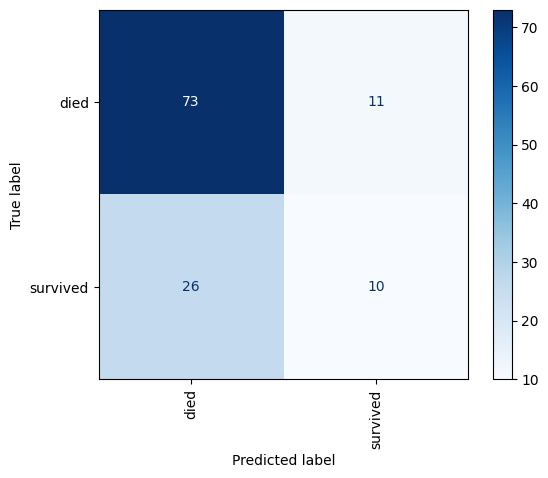

In [19]:
cm = confusion_matrix( y_val , pred  )

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['died', 'survived'])
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=90)
plt.show()

## 5.복습 문제 : titanic

### (1) 데이터 전처리

* url :  'https://raw.githubusercontent.com/DA4BAM/dataset/master/titanic_simple.csv'

**[titanic_simple 데이터 셋 정보]**

- PassengerId : 승객번호
- Survived : 생존여부(1:생존, 0:사망)
- Pclass : 객실등급(1:1등급, 2:2등급, 3:3등급)
- Name : 승객이름
- Sex : 성별(male, female)
- Age : 나이
- Fare : 운임($)
- Embarked : 승선지역(Southhampton, Cherbourg, Queenstown)

#### 1) 데이터 로딩

In [20]:
data = pd.read_csv('https://raw.githubusercontent.com/DA4BAM/dataset/master/titanic_simple.csv')
data.dropna(inplace=True)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


#### 2) 불필요한 변수 제거

In [21]:
data.drop(columns=['PassengerId', 'Name'], inplace=True)

#### 3) x,y 분할

In [24]:
target = 'Survived'
x= data.drop(target, axis =1)
y = data.loc[:, target]

#### 4) 가변수화

In [27]:
cat_cols = ['Pclass']
x = pd.get_dummies(x, columns = cat_cols, drop_first = True)

x.head()

,Age,Fare,Sex_male,Embarked_Queenstown,Embarked_Southampton,Pclass_2,Pclass_3
0,22.0,7.2500,True,False,True,False,True
1,38.0,71.2833,False,False,False,False,False
2,26.0,7.9250,False,False,True,False,True
3,35.0,53.1000,False,False,True,False,False
4,35.0,8.0500,True,False,True,False,True


#### 5) train, val 분할

In [30]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.3,random_state = 30)

### (2) 모델링

* 모델 선언
* 학습
* 예측
* 성능 검증

#### 1) 모델 선언

In [31]:
model2 = LogisticRegression()

#### 2) 학습

In [32]:
model2.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

#### 3) 예측

In [34]:
pred = model2.predict(x_val)
pred

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### 4) 검증평가
만든 모델은 얼마나 정확한지 검증해 봅시다.



In [42]:
print("정확도 비율 : ",round(accuracy_score( y_val, pred )*100,2),"%")

print("="*100)

print(classification_report(y_val, pred))

정확도 비율 :  80.37 %
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       135
           1       0.73      0.73      0.73        79

    accuracy                           0.80       214
   macro avg       0.79      0.79      0.79       214
weighted avg       0.80      0.80      0.80       214

